In [1]:
# Setup for Google Colab (optional)
import sys
if 'google.colab' in sys.modules:
    print("Running in Google Colab")
    # Install required packages
    !pip install -q py4DSTEM hyperspy scikit-image matplotlib numpy scipy
    
    # Clone the repository to access data
    !git clone -q https://github.com/NU-MSE-LECTURES/465-WINTER2026.git
    import os
    os.chdir('/content/465-WINTER2026')
    
    # Set up file handling
    from google.colab import files
    print("Colab setup complete!")
else:
    print("Running in local environment")

Running in local environment


<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_02/assignments/assignment_02_setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 02: 4D-STEM Foundations

Complete this assignment to demonstrate your understanding of 4D-STEM data analysis and calibration.


In [2]:
# Colab setup
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab. Installing requirements...")
    !pip install hyperspy ase py4DSTEM
    !git clone https://github.com/NU-MSE-LECTURES/465_Computational_Microscopy_2026.git
    print("Setup complete.")
except ImportError:
    IN_COLAB = False
    print("Not running in Google Colab.")

Not running in Google Colab.


## Task 1: Distinguish Navigation vs. Signal Axes

In your notebook, define the "Navigation Axes" (where the measurement is made, e.g., x, y scan positions).

Define the "Signal Axes" (what is measured at each point, e.g., an EELS spectrum or a 2D diffraction pattern).

Use signal.axes manager to print and verify the dimensionality of a 4D-STEM dataset (expected: 2 Navigation, 2 Signal).

In [5]:
# Your code here
import hyperspy.api as hs

si_sige = hs.load('C:/Users/wkddk/matsci465/Si-SiGe.dm4')
s = si_sige.transpose(navigation_axes=[2,3],signal_axes=[0,1]) # the navigation and signal axes in this dataset need to be swapped

s.axes_manager.navigation_axes[0].name = 'Rx'
s.axes_manager.navigation_axes[1].name = 'Ry'

s.axes_manager.signal_axes[0].name = 'Qx'
s.axes_manager.signal_axes[1].name = 'Qy'

s.axes_manager

Navigation axis name,size,index,offset,scale,units
Rx,17,0,0.0,2.0,nm
Ry,77,0,0.0,2.0,nm
Signal axis name,size,,offset,scale,units
Qx,448,,0.0,0.06208537146449089,1/nm
Qy,480,,0.0,0.06208537146449089,1/nm


## Task 2: Load and Calibrate 4D-STEM Data

Use py4DSTEM.io.read to load a 4D-STEM dataset (e.g., .dm4 or .h5).

**Note:** The dataset Si-SiGe.dm4 should be available in the raw_data folder.

Set the scan step size (real space calibration) using dataset.set_scan_step_size().

Perform Center of Mass (CoM) correction using dataset.get_diffraction_shifts() to center the unscattered beam.

In [6]:
import py4DSTEM as p4
print(f'py4DSTEM version: {p4.__version__}') # running on Python 3.11

py4DSTEM version: 0.14.0


In [7]:
sige_datacube = p4.io.import_file('C:/Users/wkddk/matsci465/Si-SiGe.dm4')
sige = sige_datacube.swap_RQ() # like before, the navigation and signal axes need to be swapped
sige.shape

(77, 17, 480, 448)

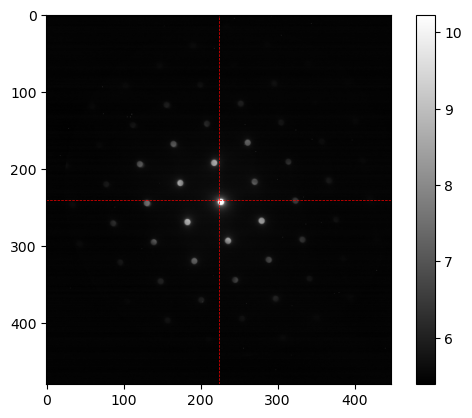

In [8]:
import numpy as np
import matplotlib.pyplot as plt

mean_dp = sige.data.mean(axis=(0,1))
plt.imshow(np.log1p(mean_dp.data),cmap='gray')
plt.colorbar()
plt.axhline(y=240,color='r',linestyle='--',linewidth=0.5)
plt.axvline(x=224,color='r',linestyle='--',linewidth=0.5)

In [57]:
from scipy.ndimage import center_of_mass, shift

sige_CoM = np.zeros(shape=(sige.data.shape[0], sige.data.shape[1], 2))

for i in range(sige.data.shape[0]):
    for j in range(sige.data.shape[1]):
        sige_CoM[i,j,0], sige_CoM[i,j,1] = center_of_mass(sige.data[i,j,:,:]) # dy, dx format

ref_CoM = center_of_mass(mean_dp.data)

In [64]:
print(f'Reference CoM: {ref_CoM}')
print(f'Select CoM from one point: {sige_CoM[70,10,:]}')

Reference CoM: (239.7202052508977, 223.63286667158408)
Select CoM from one point: [240.01866728 223.22209362]


In [59]:
sige_calib = np.empty(shape=(sige.data.shape[0],sige.data.shape[1],sige.data.shape[2],sige.data.shape[3]), dtype=np.float32)

for i in range(sige.data.shape[0]):
    for j in range(sige.data.shape[1]):
        y_shift, x_shift = ref_CoM - sige_CoM[i,j]
        sige_calib[i,j,:,:] = shift(sige.data[i,j,:,:], shift=(x_shift, y_shift), order=1, mode='nearest', prefilter=False)

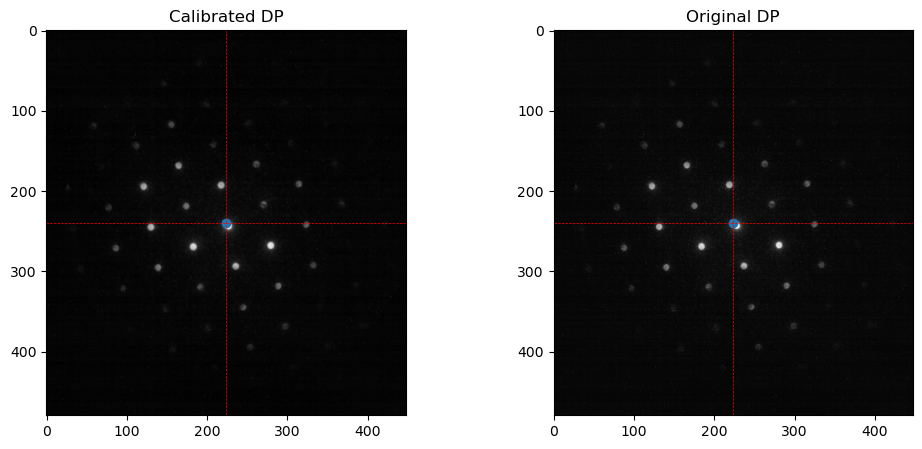

In [63]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].imshow(np.log1p(sige_calib[70,10,:,:]),cmap='gray')
ax[0].axhline(y=ref_CoM[0],color='r',linestyle='--',linewidth=0.5)
ax[0].axvline(x=ref_CoM[1],color='r',linestyle='--',linewidth=0.5)
ax[0].set_title('Calibrated DP')
ax[0].scatter(sige_CoM[70,10,1],sige_CoM[70,10,0])

ax[1].imshow(np.log1p(sige.data[70,10,:,:]),cmap='gray')
ax[1].axhline(y=ref_CoM[0],color='r',linestyle='--',linewidth=0.5)
ax[1].axvline(x=ref_CoM[1],color='r',linestyle='--',linewidth=0.5)
ax[1].set_title('Original DP')
ax[1].scatter(sige_CoM[70,10,1],sige_CoM[70,10,0])

Reciprocal space calibration:
  Pixel size: 0.06208537146449089 1/nm per pixel
  qx range: [-14.883, 14.856] 1/nm
  qy range: [-13.884, 13.868] 1/nm


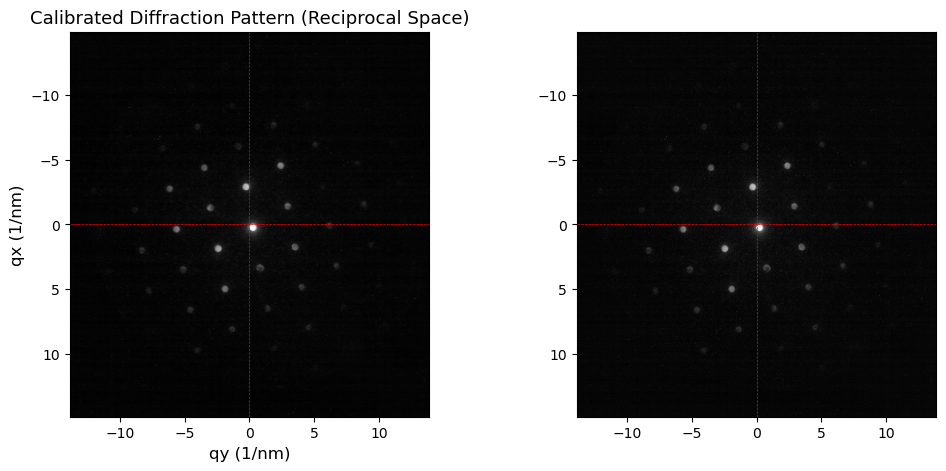

In [280]:
reciprocal_pixel_size = 0.06208537146449089 # taken from Hyperspy axis manager
origin_x = ref_CoM[0]
origin_y = ref_CoM[1]

qx = (np.arange(sige.shape[2]) - origin_x) * reciprocal_pixel_size
qy = (np.arange(sige.shape[3]) - origin_y) * reciprocal_pixel_size

print(f"Reciprocal space calibration:")
print(f"  Pixel size: {reciprocal_pixel_size} 1/nm per pixel")
print(f"  qx range: [{qx.min():.3f}, {qx.max():.3f}] 1/nm")
print(f"  qy range: [{qy.min():.3f}, {qy.max():.3f}] 1/nm")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

im = ax[0].imshow(np.log1p(sige_calib[32,16,:,:]), 
               extent=[qy.min(), qy.max(), qx.max(), qx.min()],
               cmap='gray', origin='upper')
ax[0].set_xlabel('qy (1/nm)', fontsize=12)
ax[0].set_ylabel('qx (1/nm)', fontsize=12)
ax[0].set_title('Calibrated Diffraction Pattern (Reciprocal Space)', fontsize=13)
ax[0].axhline(y=0, color='r', linestyle='--', linewidth=0.5)
ax[0].axvline(x=0, color='r', linestyle='--', linewidth=0.5)
#plt.colorbar(im, ax=ax, label='Intensity (log scale)')
#plt.tight_layout()

ax[1].imshow(np.log1p(sige.data[32,16,:,:]),extent=[qy.min(), qy.max(), qx.max(), qx.min()], cmap='gray', origin='upper')
ax[1].axhline(y=0, color='r',linestyle='--',linewidth=0.5)
ax[1].axvline(x=0, color='r',linestyle='--',linewidth=0.5)

## Task 3: Virtual Detector Reconstruction

Generate a Virtual Bright Field (BF) image by integrating the central transmitted disk.

Generate an Annular Dark Field (ADF) image by integrating the scattered electrons in an outer ring.

Compare the Z-contrast in the ADF image to the diffraction contrast in the BF image.

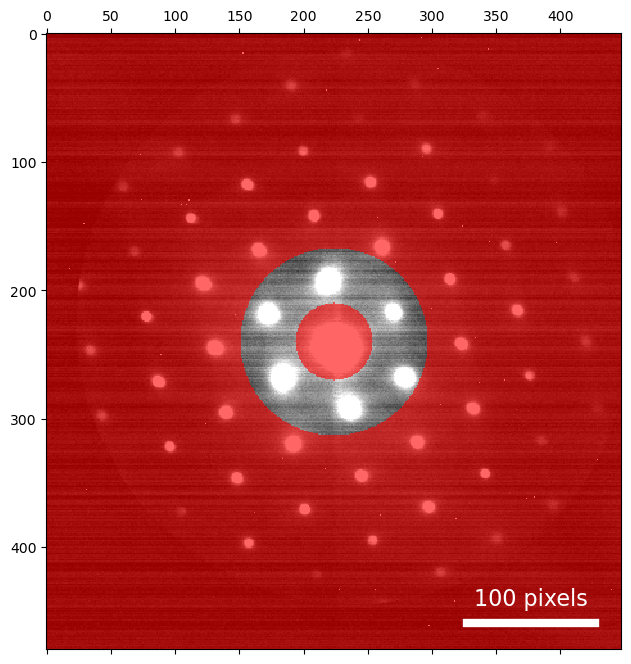

100%|█████████████████████████████████████████████████████████████████████████████| 1309/1309 [00:01<00:00, 799.04it/s]


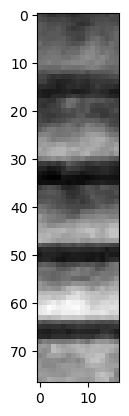

In [290]:
center = (240, 224)
radii = (30, 73)

sige.position_detector(mode = 'annular', geometry = (center, radii))
virtual_img = sige.get_virtual_image(mode = 'annulus', geometry = ((center),radii), name = 'dark_field')
plt.imshow(virtual_img.data,cmap='gray')

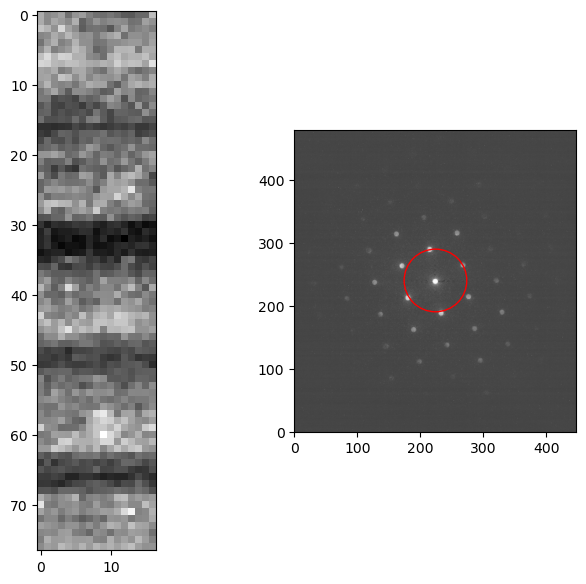

In [42]:
# Your code here

# BF image
virtual_BF_img = np.sum(sige.data, axis=(2,3))
fig, ax = plt.subplots(1,2,figsize=(8,7))
ax[0].imshow(virtual_BF_img,cmap='gray')

# ADF image

# known reflection in SiGe at (004)
#d = 5.54/2 # interplanar spacing of the (004) plane is given by the lattice parameter a (in this case, 5.54 Angstroms) divided by sqrt(h^2 + k^2 + l^2)
#q = 1/d # reciprocal space dimensions of (004) plane

reciprocal_scale = 0.06208537146449089 # 1/nm
xcoord = (np.arange(sige.data.shape[2]) - sige.data.shape[2] / 2) * reciprocal_scale
ycoord = (np.arange(sige.data.shape[3]) - sige.data.shape[3] / 2) * reciprocal_scale
ax[1].imshow(np.log1p(sige.data[60, 15, :, :]), cmap='gray', extent=[qy.min(), qy.max(), qx.min(), qx.max()])

import matplotlib.patches as patches
# center position is 224.5 x 244.5 pixels. in reciprocal space, the position would be...
circx = 224
circy = 240
#circx = (241 - 240)
#circy = (219 - 224)
circ = patches.Circle((circx, circy), radius=800*reciprocal_scale, color='r', fill=False)
ax[1].add_patch(circ)

# for the purposes of constructing the ADF image, scan from radii of 40*reciprocal_scale to 60*reciprocal_scale
#print(q)
#print(50*reciprocal_scale)

## Task 4: Basic 4D-STEM Visualization

Launch the interactive 4D-STEM browser using dataset.show() (if using a local GUI) or py4D.show_image().

Export a publication-quality figure of a virtual ADF image with a scale bar and a perceptually uniform colormap (e.g., magma).

In [2]:
# Your code here




from matplotlib.patches import Rectangle
if scale_bar_pixels < adf_image.shape[1] - 5:
    # Position scale bar in bottom-left corner
    bar_x, bar_y = 2, adf_image.shape[0] - 4
    scale_bar = Rectangle((bar_x, bar_y), scale_bar_pixels, 1, fill=True, color='white', linewidth=1)
    ax.add_patch(scale_bar)
    ax.text(bar_x + scale_bar_pixels/2, bar_y - 1, f'{scale_bar_length} nm', ha='center', va='top', 
            color='white', fontsize=10, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Integrated Intensity (a.u.)', fontsize=12)

plt.tight_layout()
plt.savefig('virtual_adf_figure_sisige.png', dpi=300, bbox_inches='tight')
plt.show()

## Task 5: Finalize and Submit

Update your README.md with a brief explanation of how virtual detectors allow post-acquisition imaging.

Push the completed Week 02 notebook to your GitHub repository.

Submit the repository link on Canvas.

In [ ]:
# Your code here